<a href="https://colab.research.google.com/github/Shravaniipagare/Genomic-analysis/blob/main/gemoic_sequence_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Genomic Sequence Analysis using Biopython
**Author:** Shravani Pagare  
**Tools:** Python, Biopython, Matplotlib, Seaborn, NCBI Entrez  
**Goal:** Fetch gene sequences from NCBI, compute GC content, nucleotide frequency, pairwise alignment, and visualize results.

In [1]:
!pip install biopython

from Bio import Entrez, SeqIO
from Bio import pairwise2
from Bio.pairwise2 import format_alignment
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import Counter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 62.3 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


Fetching ids of organisms

In [2]:
Entrez.email = "shravanipagare16@gmail.com"

# Fetching cytochrome b gene from 5 organisms
accession_ids = {
    "Human":      "NC_012920",
    "Chimpanzee": "NC_001643",
    "Mouse":      "NC_005089",
    "Rat":        "NC_001665",
    "Zebrafish":  "NC_002333"
}

sequences = {}
for organism, acc_id in accession_ids.items():
    handle = Entrez.efetch(db="nucleotide", id=acc_id,
                           rettype="fasta", retmode="text")
    record = SeqIO.read(handle, "fasta")
    sequences[organism] = record.seq[:1000]  # first 1000 bases
    print(f"Fetched: {organism} — {len(sequences[organism])} bases")

Fetched: Human — 1000 bases
Fetched: Chimpanzee — 1000 bases
Fetched: Mouse — 1000 bases
Fetched: Rat — 1000 bases
Fetched: Zebrafish — 1000 bases


GC Content

In [3]:
def gc_content(seq):
    g = seq.count("G")
    c = seq.count("C")
    return round((g + c) / len(seq) * 100, 2)

gc_data = {org: gc_content(seq) for org, seq in sequences.items()}
print("GC Content (%):", gc_data)

GC Content (%): {'Human': 45.6, 'Chimpanzee': 44.2, 'Mouse': 35.5, 'Rat': 37.7, 'Zebrafish': 33.1}


Nucleotide Frequency

In [4]:
nt_data = []
for org, seq in sequences.items():
    counts = Counter(str(seq))
    nt_data.append({"Organism": org, "A": counts["A"],
                    "T": counts["T"], "G": counts["G"], "C": counts["C"]})

df_nt = pd.DataFrame(nt_data)
print(df_nt)

     Organism    A    T    G    C
0       Human  311  233  146  310
1  Chimpanzee  331  227  183  259
2       Mouse  382  263  158  197
3         Rat  372  251  165  212
4   Zebrafish  336  333  143  188


Visualize GC content (bar chart)


/tmp/ipykernel_17030/4241936938.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(gc_data.keys()), y=list(gc_data.values()), palette="Blues_d")


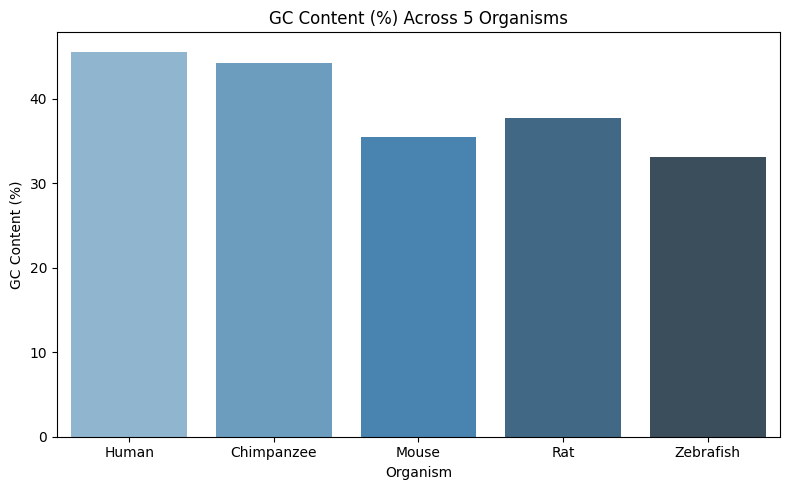

In [5]:
plt.figure(figsize=(8, 5))
sns.barplot(x=list(gc_data.keys()), y=list(gc_data.values()), palette="Blues_d")
plt.title("GC Content (%) Across 5 Organisms")
plt.ylabel("GC Content (%)")
plt.xlabel("Organism")
plt.tight_layout()
plt.savefig("gc_content.png")
plt.show()

visualize nucleotide frequency (grouped bar)

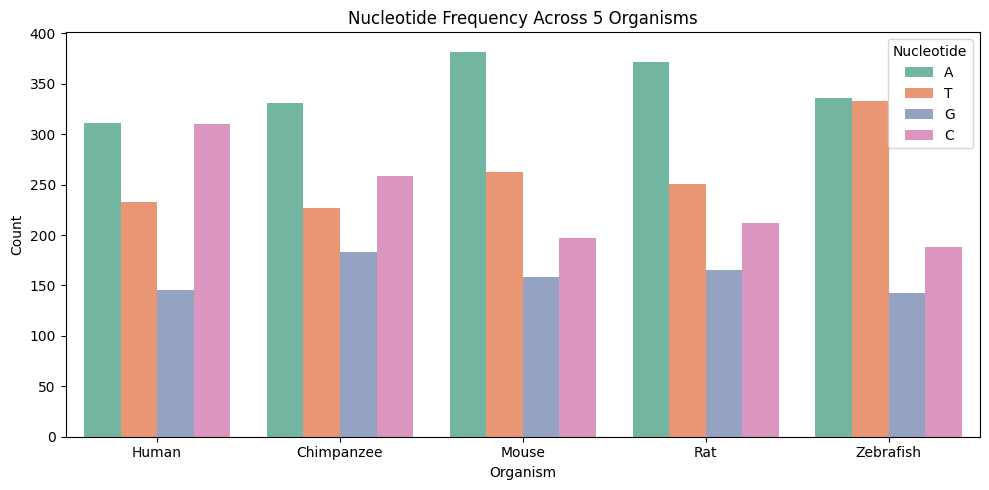

In [6]:
df_melt = df_nt.melt(id_vars="Organism", var_name="Nucleotide", value_name="Count")
plt.figure(figsize=(10, 5))
sns.barplot(data=df_melt, x="Organism", y="Count", hue="Nucleotide", palette="Set2")
plt.title("Nucleotide Frequency Across 5 Organisms")
plt.tight_layout()
plt.savefig("nucleotide_frequency.png")
plt.show()

Pairwise alignment (Human vs others)


In [7]:
human_seq = str(sequences["Human"])[:200]

for org, seq in sequences.items():
    if org == "Human":
        continue
    alignments = pairwise2.align.globalxx(human_seq, str(seq)[:200])
    score = alignments[0].score
    print(f"Human vs {org}: Alignment score = {score}")

Human vs Chimpanzee: Alignment score = 124.0
Human vs Mouse: Alignment score = 121.0
Human vs Rat: Alignment score = 121.0
Human vs Zebrafish: Alignment score = 122.0


Exporting results to csv file

In [8]:
df_gc = pd.DataFrame(list(gc_data.items()), columns=["Organism", "GC_Content_%"])
df_gc.to_csv("gc_content_results.csv", index=False)
df_nt.to_csv("nucleotide_frequency_results.csv", index=False)
print("Results exported to CSV files.")

Results exported to CSV files.


## Rosalind Problems Solved
- DNA: Counting nucleotides in a DNA string
- RNA: Transcribing DNA to RNA
- PROT: Translating RNA to Protein
- GC: Computing GC content
- FASTA: Parsing FASTA files
- HAMM: Counting point mutations
- REVC: Complementing a strand
- PERM: Enumerating permutations
- SUBS: Finding a motif in DNA
- CONS: Consensus and profile